<a href="https://colab.research.google.com/github/date-with-models/analytics_edu/blob/task_0/pandasmatplotlibtasks_only_george_from_gcolab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Всё необходимое для выполнения данной лабораторной работы!
import requests
from time import sleep

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Задание 1. Парсинг - 10 баллов

В этом задании Вам предстоит работать с API сайта <a target="_blank" href="hh.ru">hh.ru</a>. Документация доступна по <a target="_blank" href="https://github.com/hhru/api/blob/master/docs/vacancies.md#search">ссылке</a>.

**Задача:**
1. выбрать 5 интересующих вас профессий (не смежных, т.е. Аналатик и Data Engineer не считается корректным)
2. затем получить доступные по данным профессиям вакансии в Москве и выделить их физические координаты
3. нанести полученные координаты на карту местоположения компаний

*Пример запроса для профессии:*

In [ ]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': "Физик-ядерщик",
    'area': 1,
    'page': 0,
    'per_page': 10
}

data = requests.get(URL, params).json()
data

{'items': [],
 'found': 0,
 'pages': 1,
 'page': 0,
 'per_page': 10,
 'clusters': None,
 'arguments': None,
 'fixes': None,
 'suggests': None,
 'alternate_url': 'https://hh.ru/search/vacancy?area=1&enable_snippets=true&items_on_page=10&text=%D0%A4%D0%B8%D0%B7%D0%B8%D0%BA-%D1%8F%D0%B4%D0%B5%D1%80%D1%89%D0%B8%D0%BA'}

Если Ваш запрос прошел успешно, то вы получите следующие ключи (значения данных ключей вы найдете по ссылке на документацию):

In [ ]:
data.keys()

dict_keys(['items', 'found', 'pages', 'page', 'per_page', 'clusters', 'arguments', 'fixes', 'suggests', 'alternate_url'])

Выберете для нас 5 наиболее интересных специальностей и получите по ним имеющиеся вакансии:

In [ ]:
URL = 'https://api.hh.ru/vacancies'

params = {
    'text': 'Уборщик',
    'area': 1,
    'page': 0,
    'per_page': 1
}

data = requests.get(URL, params).json()
data

{'items': [{'id': '116712496',
   'premium': False,
   'name': 'Уборщик офисных помещений',
   'department': None,
   'has_test': False,
   'response_letter_required': False,
   'area': {'id': '1', 'name': 'Москва', 'url': 'https://api.hh.ru/areas/1'},
   'salary': {'from': 80000, 'to': None, 'currency': 'RUR', 'gross': False},
   'type': {'id': 'open', 'name': 'Открытая'},
   'address': {'city': 'Москва',
    'street': 'Большой Саввинский переулок',
    'building': '12с6',
    'lat': 55.733239,
    'lng': 37.563709,
    'description': None,
    'raw': 'Москва, Большой Саввинский переулок, 12с6',
    'metro': None,
    'metro_stations': [],
    'id': '17463940'},
   'response_url': None,
   'sort_point_distance': None,
   'published_at': '2025-02-03T14:56:19+0300',
   'created_at': '2025-02-03T14:56:19+0300',
   'archived': False,
   'apply_alternate_url': 'https://hh.ru/applicant/vacancy_response?vacancyId=116712496',
   'show_logo_in_search': None,
   'insider_interview': None,
   'u

In [ ]:
class addresses:
    def __init__(self, name, lat, lng):
        self.name = name
        self.lat = lat
        self.lng = lng

    def print_info(self):
        print(f"Name: {self.name}, Lat: {self.lat}, Lng: {self.lng}")



In [ ]:
list_of_addresses = []
for _ in range(data['pages']):
    params['page'] = _

    for i in range(data['per_page']):
      response_data = requests.get(URL, params).json()
      try:
        list_of_addresses.append(addresses(name = response_data['items'][i]['employer']['name'],
                                     lat = response_data['items'][i]['address']['lat'],
                                     lng = response_data['items'][i]['address']['lng']))
      except:
        continue
    sleep(2)
for _ in list_of_addresses:
  addresses.print_info(_)

KeyboardInterrupt: 

In [ ]:
print(len(list_of_addresses))

1380


Посчитайте сколько всего найдено вакансий:

In [ ]:
print(data['found'])

2718


Создайте структуру данных, которая будет хранить в себе имя компании и ее координаты (широта и долгота):

Создайте экземпляр этой структуры данных для каждой компании, которая выставила вакансию:

Найдите количество вакансий, у которых заданы координаты (значения данных может быть пустым):

In [ ]:
counter = 0
for _ in range(len(list_of_addresses)):
  if list_of_addresses[_].lat == None or list_of_addresses[_].lng == None:
    counter += 1
print(len(list_of_addresses) - counter)

1319


Отберите вакансии, которые расположены в пределах МКАД (можно грубо):

Постройте график в координатах "широта-долгота" для отображения вакансий внутри МКАД (не забывайте прописать прозрачность, чтобы увидеть скопления):

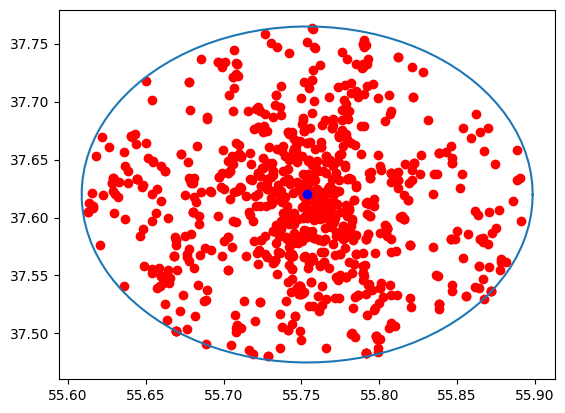

In [ ]:
сenter_lat = 55.753674
center_lng = 37.619881
point_lat = 55.894918
point_lng = 37.652472


radius = np.sqrt((point_lat - center_lat)**2 + (point_lng - center_lng)**2)

for _ in range(len(list_of_addresses)):
  if list_of_addresses[_].lat != None and list_of_addresses[_].lng != None:
    if np.sqrt((list_of_addresses[_].lat - center_lat)**2 + (list_of_addresses[_].lng - center_lng)**2) <= radius:
      plt.plot(list_of_addresses[_].lat, list_of_addresses[_].lng, 'ro')


angles = np.linspace(0, 2*np.pi, 100)
circle_lats = center_lat + radius * np.cos(angles)
circle_lngs = center_lng + radius * np.sin(angles)

plt.plot(circle_lats, circle_lngs)

plt.plot(center_lat, center_lng, 'bo', label='Center')

**Сделайте выводы о проделанной работе:**

Вам предстоит проанализировать датасет, содержащий информацию об бриллианта, их стоимости и остальных характеристиках.



Поясним значения хранящиеся в колонках:
*   `cut` - огранка бриллианта (относится к одной из примерно 10 наиболее распространенных)
*   `color` - цвет бриллианта, прозрачные бриллианты имеют градацию `D-Z`, "более высокие" буквы - более желтоватые, но часто имеют лучшие значения, поскольку цвет трудно определить один раз в кольце
*   `clarity` - чистота бриллианта, наличие включений (внутренних дефектов), чем меньше и мельче, тем лучше
*   `carat_weight` - масса бриллианта (слабо связана с размером бриллианта, т.к. огранка и качество огранки, как правило, играют большую роль)
*   `cut_quality` - качество ограники по системе оценки GIA Cut
*   `lab` - лаборатория оценивания
*   `meas_length` - длина бриллианта
*   `meas_width` - ширина бриллианта
*   `meas_depth` - глубина бриллианта
*   `total_sales_price` - цена бриллианта в долларах.
*    **и прочие колонки**

Скачаем данные:

In [ ]:
!gdown 10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
# если работайте в jupyter то скачайте датасет с https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8

Downloading...
From: https://drive.google.com/uc?id=10OJ30qlkE-7zK4JuVTDMY3U4nRB4tu_8
To: /content/diamonds.csv
100% 35.4M/35.4M [00:00<00:00, 107MB/s]


Создадим DataFrame:

In [ ]:
import pandas as pd

diamonds = pd.read_csv("diamonds.csv")

Выведете первые 5 строк датасета:

In [ ]:
diamonds.head(5)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,...,meas_depth,girdle_min,girdle_max,fluor_color,fluor_intensity,fancy_color_dominant_color,fancy_color_secondary_color,fancy_color_overtone,fancy_color_intensity,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.79,M,M,unknown,NaN,unknown,unknown,unknown,unknown,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,...,1.78,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.77,TN,M,unknown,NaN,unknown,unknown,unknown,unknown,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,...,1.78,M,STK,unknown,NaN,unknown,unknown,unknown,unknown,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,...,1.82,STK,STK,unknown,NaN,unknown,unknown,unknown,unknown,200


Найдите количество бриллиантов всего в данном датасете:

In [ ]:
len(diamonds)

219703

Выведите максимальную и минимальную цену бриллианта в формате `номер - цена`:

In [ ]:
print(diamonds['Unnamed: 0'][diamonds['total_sales_price'].idxmax()], '-', diamonds['total_sales_price'].max())
print(diamonds['Unnamed: 0'][diamonds['total_sales_price'].idxmin()], '-', diamonds['total_sales_price'].min())

219703 - 1449881
0 - 200


Посчитайте количество пропусков (пропуском считается значение `unknown` или `None`):

In [ ]:
counter = 0
for _ in range(len(diamonds)):
    for i in diamonds.columns:
      if diamonds[i][_] == 'unknown' or diamonds[i][_] == None:
        counter += 1
print(counter)

1746027


Найдите в каких столбцах присутствуют пропуски:

In [ ]:
missing_columns = []
for i in diamonds.columns:
  for _ in range(len(diamonds)):
    if diamonds[i].isnull().any() == 'unknown' or (diamonds[i] == None).any:
      missing_columns.append(i)
      break
print(missing_columns)

['Unnamed: 0', 'cut', 'color', 'clarity', 'carat_weight', 'cut_quality', 'lab', 'symmetry', 'polish', 'eye_clean', 'depth_percent', 'table_percent', 'meas_length', 'meas_width', 'meas_depth', 'girdle_min', 'girdle_max', 'total_sales_price']


В нашем датасете присутствуют колонки, которые начинаются с `fancy_color_` или `fluor_`. Большинство значений в этих колонках - `unknown` или `None`, поэтому мы считаем их малоинформативными.

Ваша задача:

найти количество таких колонок, которые начинаются с `fancy_color_` или `fluor_`:

In [ ]:
fancy_color_cols = [col for col in diamonds.columns if col.startswith('fancy_color_')]
fluor_cols = [col for col in diamonds.columns if col.startswith('fluor_')]

total_cols = len(fancy_color_cols) + len(fluor_cols)

total_cols


6

найти количество информативных (не `None` или `unknown`) значений в этих колонках:

In [ ]:
informative_count = 0
for col in fancy_color_cols + fluor_cols:
    informative_count += diamonds[col].apply(lambda x: x not in ['unknown', 'None']).sum()
informative_count


256727

удалить данные колонки из датасета, сохранив изменения (в дальнейшем работаем измененным датасетом):

In [ ]:
columns_to_drop = fancy_color_cols + fluor_cols
diamonds = diamonds.drop(columns=columns_to_drop)

diamonds.head(5)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,culet_size,culet_condition,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,N,unknown,62.7,59.0,2.85,2.87,1.79,M,M,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,N,unknown,61.9,59.0,2.84,2.89,1.78,STK,STK,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,unknown,61.1,59.0,2.88,2.90,1.77,TN,M,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,unknown,unknown,62.0,59.0,2.86,2.88,1.78,M,STK,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,N,unknown,64.9,58.5,2.79,2.83,1.82,STK,STK,200


Проделайте тоже самое для колонок, начинающихся с `culet_`:

In [ ]:
culet_cols = [col for col in diamonds.columns if col.startswith('culet_')]
diamonds = diamonds.drop(columns=culet_cols)

diamonds.head(5)

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,62.7,59.0,2.85,2.87,1.79,M,M,200
1,1,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,61.9,59.0,2.84,2.89,1.78,STK,STK,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,61.1,59.0,2.88,2.90,1.77,TN,M,200
3,3,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,62.0,59.0,2.86,2.88,1.78,M,STK,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,64.9,58.5,2.79,2.83,1.82,STK,STK,200


Посчитайте сколько бы стоил (в тысячах долларов) сейф, в котором хранились бы все бриллианты из датасета:

In [ ]:
diamonds['total_sales_price'].sum() / 1000

1517721.991

Немного необоснованных манипуляций.

Выберите из датасета строки с четными индексами и выведете значения (не меняя нумерацию индексов):

In [ ]:
diamonds.iloc[::2]

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,62.7,59.0,2.85,2.87,1.79,M,M,200
2,2,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,61.1,59.0,2.88,2.90,1.77,TN,M,200
4,4,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Excellent,unknown,64.9,58.5,2.79,2.83,1.82,STK,STK,200
6,6,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,64.0,57.0,2.85,2.88,1.84,STK,STK,200
8,8,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,63.5,59.5,2.89,2.92,1.85,STK,TK,200
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219694,219695,Round,D,IF,12.52,Excellent,HRD,Excellent,Excellent,unknown,62.1,58.0,14.84,14.91,9.24,unknown,unknown,1121792
219696,219697,Oval,H,VS2,18.88,unknown,GIA,Excellent,Excellent,unknown,57.1,55.0,21.34,15.23,8.69,TN,STK,1132347
219698,219699,Round,E,VS1,10.65,Excellent,GIA,Excellent,Excellent,unknown,61.3,58.0,14.06,14.18,8.66,M,STK,1210692
219700,219701,Round,E,VS1,18.07,Excellent,GIA,Excellent,Excellent,unknown,60.2,59.0,17.06,17.10,10.20,TN,M,1315496


А теперь с индексами, кратными 6:

In [ ]:
diamonds.iloc[::6]

,Unnamed: 0,cut,color,clarity,carat_weight,cut_quality,lab,symmetry,polish,eye_clean,depth_percent,table_percent,meas_length,meas_width,meas_depth,girdle_min,girdle_max,total_sales_price
0,0,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,62.7,59.0,2.85,2.87,1.79,M,M,200
6,6,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,64.0,57.0,2.85,2.88,1.84,STK,STK,200
12,12,Round,E,VVS2,0.09,Very Good,IGI,Very Good,Very Good,unknown,61.8,58.5,2.85,2.89,1.77,STK,TK,200
18,18,Round,E,VVS2,0.09,Excellent,IGI,Very Good,Very Good,unknown,61.0,60.0,2.91,2.92,1.78,M,M,200
24,24,Round,L,I1,0.34,Excellent,IGI,Excellent,Excellent,unknown,0.0,0.0,0.00,0.00,0.00,unknown,unknown,204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
219678,219679,Round,G,VS1,10.23,Excellent,GIA,Excellent,Excellent,unknown,62.7,55.0,13.82,13.92,8.69,TN,M,859320
219684,219685,Radiant,unknown,I1,0.89,unknown,GIA,Good,Good,unknown,63.8,57.0,6.44,4.96,3.16,TK,VTK,982560
219690,219691,Round,D,VVS2,10.10,Excellent,GIA,Excellent,Excellent,unknown,59.4,59.0,14.07,14.15,8.39,M,STK,1040739
219696,219697,Oval,H,VS2,18.88,unknown,GIA,Excellent,Excellent,unknown,57.1,55.0,21.34,15.23,8.69,TN,STK,1132347


Выберете из датасета только категорильные признаки и выведете датасет:

In [ ]:
categorical_cols = diamonds.select_dtypes(include=['object']).columns
categorical_diamonds = diamonds[categorical_cols]
categorical_diamonds

,cut,color,clarity,cut_quality,lab,symmetry,polish,eye_clean,girdle_min,girdle_max
0,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,unknown,M,M
1,Round,E,VVS2,Very Good,IGI,Very Good,Very Good,unknown,STK,STK
2,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,unknown,TN,M
3,Round,E,VVS2,Excellent,IGI,Very Good,Very Good,unknown,M,STK
4,Round,E,VVS2,Very Good,IGI,Very Good,Excellent,unknown,STK,STK
...,...,...,...,...,...,...,...,...,...,...
219698,Round,E,VS1,Excellent,GIA,Excellent,Excellent,unknown,M,STK
219699,Radiant,unknown,VS2,unknown,GIA,Very Good,Very Good,unknown,TK,XTK
219700,Round,E,VS1,Excellent,GIA,Excellent,Excellent,unknown,TN,M
219701,Princess,unknown,SI2,unknown,GIA,Good,Good,unknown,XTN,VTK


### Построение графиков

**Требования к графику:**

1.   График должен быть подписан
2.   Оси должны быть подписаны
3.   Должна быть легенда графика
4.   График должен быть информативным (желательно без сильных выбросов)

**Все надписи на русском языке!**

>**Примечание**
>
>График необходимо строить для очищенных данных - в них не должно быть пропусков по осям, по которым строите график. При этом **не перезатирайте** имеющийся датафрейм!

Постройте график `цвет бриллианта - стоимость`:

<ipython-input-61-3b4d16e2dbbd>:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  diamonds_cleaned['total_sales_price'] = pd.to_numeric(diamonds_cleaned['total_sales_price'], errors='coerce')
<ipython-input-61-3b4d16e2dbbd>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='color', y='total_sales_price', data=diamonds_cleaned, palette='viridis')


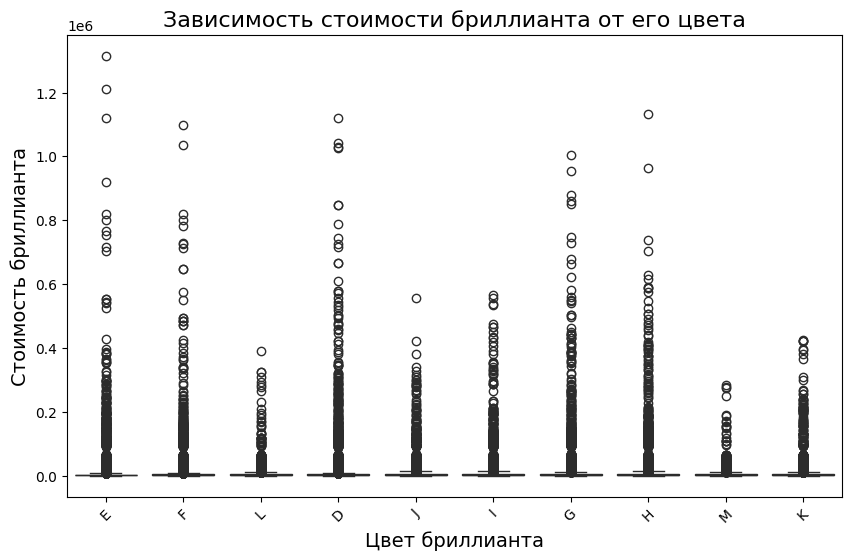

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
# Создаем копию датафрейма для работы с очищенными данными
diamonds_cleaned = diamonds.copy()

# Удаляем строки с пропусками в столбцах 'color' и 'total_sales_price'
missing_values = ['unknown', 'None', 'NaN']

diamonds_cleaned = diamonds_cleaned[~diamonds_cleaned['color'].isin(missing_values)]

# Преобразуем 'total_sales_price' в числовой тип
diamonds_cleaned['total_sales_price'] = pd.to_numeric(diamonds_cleaned['total_sales_price'], errors='coerce')
diamonds_cleaned = diamonds_cleaned[~diamonds_cleaned['total_sales_price'].isin(missing_values)]


# Строим график
plt.figure(figsize=(10, 6))
sns.boxplot(x='color', y='total_sales_price', data=diamonds_cleaned, palette='viridis')
plt.title('Зависимость стоимости бриллианта от его цвета', fontsize=16)
plt.xlabel('Цвет бриллианта', fontsize=14)
plt.ylabel('Стоимость бриллианта', fontsize=14)
plt.xticks(rotation=45)
plt.show()


<ipython-input-63-8fb4f404fe88>:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='color', y='total_sales_price', data=color_price, palette='viridis')


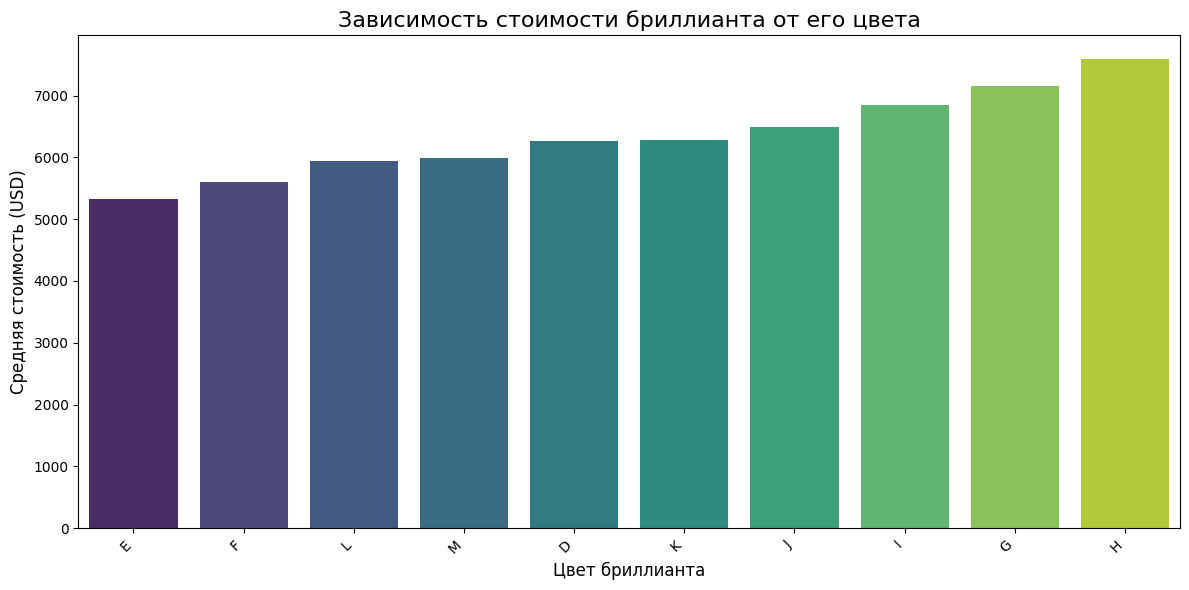

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
diamonds = pd.read_csv("diamonds.csv")

# Drop columns starting with 'fancy_color_', 'fluor_', and 'culet_'
columns_to_drop = [col for col in diamonds.columns if col.startswith('fancy_color_') or col.startswith('fluor_') or col.startswith('culet_')]
diamonds_cleaned = diamonds.drop(columns=columns_to_drop)

# Replace 'unknown' with NaN
diamonds_cleaned = diamonds_cleaned.replace('unknown', pd.NA)

# Remove rows with NaN values in 'color' or 'total_sales_price'
diamonds_cleaned = diamonds_cleaned.dropna(subset=['color', 'total_sales_price'])

# Group by 'color' and calculate the mean price
color_price = diamonds_cleaned.groupby('color')['total_sales_price'].mean().reset_index()

# Sort by price for better visualization
color_price = color_price.sort_values('total_sales_price')

# Create the plot
plt.figure(figsize=(12, 6))
sns.barplot(x='color', y='total_sales_price', data=color_price, palette='viridis')

# Customize the plot
plt.title('Зависимость стоимости бриллианта от его цвета', fontsize=16)
plt.xlabel('Цвет бриллианта', fontsize=12)
plt.ylabel('Средняя стоимость (USD)', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


Постройте график `лабараторная оценка - кол-во бриллиантов`:

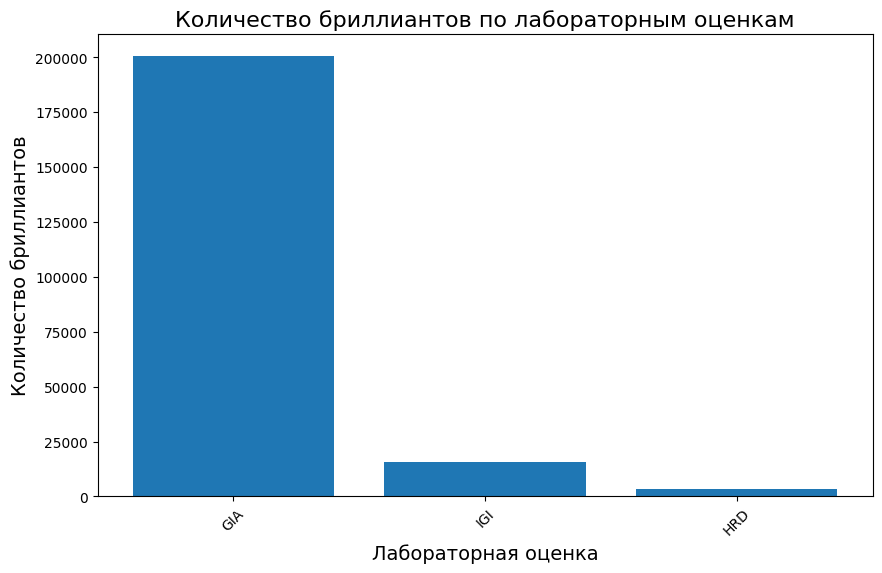

In [ ]:
# prompt: Постройте график лабараторная оценка - кол-во бриллиантов:

import matplotlib.pyplot as plt
# Создаем копию датафрейма для работы с очищенными данными
diamonds_cleaned = diamonds.copy()

# Удаляем строки с пропусками в столбцах 'lab'
missing_values = ['unknown', 'None', 'NaN']
diamonds_cleaned = diamonds_cleaned[~diamonds_cleaned['lab'].isin(missing_values)]

# Строим график
plt.figure(figsize=(10, 6))
lab_counts = diamonds_cleaned['lab'].value_counts()
plt.bar(lab_counts.index, lab_counts.values)
plt.title('Количество бриллиантов по лабораторным оценкам', fontsize=16)
plt.xlabel('Лабораторная оценка', fontsize=14)
plt.ylabel('Количество бриллиантов', fontsize=14)
plt.xticks(rotation=45)
plt.show()


Постройте график `вес бриллианта - стоимость`:

Постройте график `система оценки GIA Cut - кол-во бриллиантов`:

Сделайте выводы по построенным графикам